# CNASim Performance

The experiment evaluates tree reconstruction performance on CNAsim data. This notebook shows the workflow steps.

In [1]:
# autoreload
%load_ext autoreload
%autoreload 2

In [2]:
import os

import scgenome.plotting as pl
import anndata
from Bio import Phylo
from io import StringIO

from cellmates.utils.tree_utils import write_newick, nxtree_to_newick, newick_to_nx, make_gt_tree_dist


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# data is generated from CNAsim

In [4]:
# converted to anndata

In [16]:
data_path = "../../results/data/R2_N50_M100_K2_L2_E10.04_E20.1_C2"

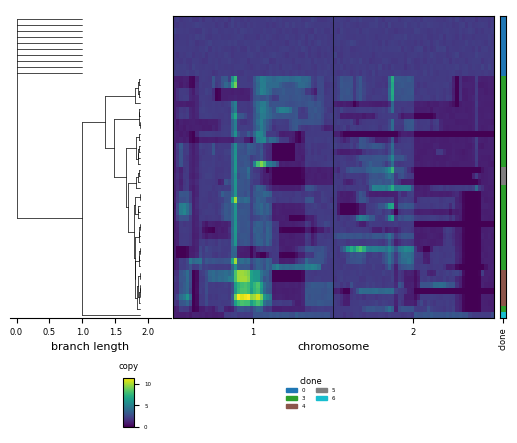

In [17]:
# plot example
adata = anndata.read_h5ad(os.path.join(data_path, "input.h5ad"))
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree, annotation_fields=['clone'], raw=True)

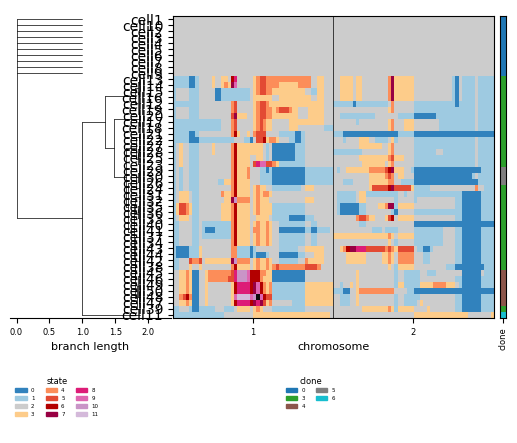

In [18]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree, annotation_fields=['clone'], show_cell_ids=True)

# GT copy number distances

['cell11', 'cell12', 'cell13', 'cell14', 'cell15', 'cell16', 'cell17', 'cell18', 'cell19', 'cell20', 'cell21', 'cell22', 'cell23', 'cell24', 'cell25', 'cell26', 'cell27', 'cell28', 'cell29', 'cell30', 'cell31', 'cell32', 'cell33', 'cell34', 'cell35', 'cell36', 'cell37', 'cell38', 'cell39', 'cell40', 'cell41', 'cell42', 'cell43', 'cell44', 'cell45', 'cell46', 'cell47', 'cell48', 'cell49', 'cell50']


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


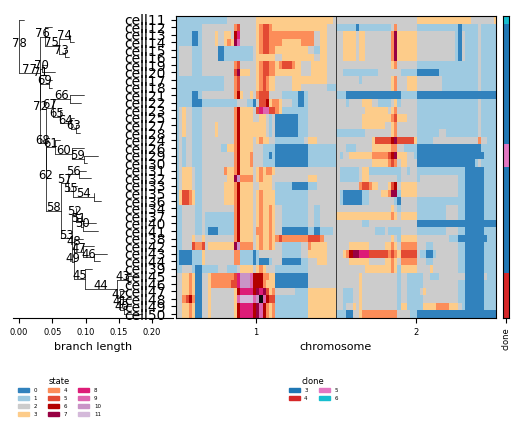

In [19]:
# use tree from cn-derived branch lengths
cell_names = adata[~adata.obs['normal']].obs_names.tolist()
print(cell_names)
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=bio_tree_cn_lengths, annotation_fields=['clone'], show_cell_ids=True)

In [20]:
gt_tree_nwk = adata.uns['cell-tree-newick']
print(gt_tree_nwk)

(cell1:1.0,cell10:1.0,cell2:1.0,cell3:1.0,cell4:1.0,cell5:1.0,cell6:1.0,cell7:1.0,cell8:1.0,cell9:1.0,(((((cell13:0.01698567688120436,cell14:0.01698567688120436)ancestor7:0.01156735490011259,(cell15:0.01861368344489383,cell16:0.01861368344489383)ancestor8:0.00993934833642312)ancestor4:0.04985854301231539,cell12:0.07841157479363234)ancestor2:0.451969907631516,(((cell19:0.0062573761025448,cell20:0.0062573761025448)ancestor10:0.00106069172124682,(cell17:0.00314896280997377,cell18:0.00314896280997377)ancestor9:0.00416910501381785)ancestor5:0.39048952473042536,(((cell21:0.00505219416551859,cell22:0.00505219416551859)ancestor13:0.06026010270833844,(((cell27:0.00617347324037906,cell28:0.00617347324037906)ancestor21:0.01701979324466793,cell25:0.02319326648504699)ancestor17:0.00122457729241363,cell23:0.02441784377746061)ancestor14:0.04089445309639642)ancestor11:0.13939492886751864,((((cell29:0.00908387900190482,cell30:0.00908387900190482)ancestor22:0.01527141491713022,cell26:0.02435529391903504

In [21]:
print(bio_tree)

Tree(rooted=False, weight=1.0)
    Clade(name='root')
        Clade(branch_length=1.0, name='cell1')
        Clade(branch_length=1.0, name='cell10')
        Clade(branch_length=1.0, name='cell2')
        Clade(branch_length=1.0, name='cell3')
        Clade(branch_length=1.0, name='cell4')
        Clade(branch_length=1.0, name='cell5')
        Clade(branch_length=1.0, name='cell6')
        Clade(branch_length=1.0, name='cell7')
        Clade(branch_length=1.0, name='cell8')
        Clade(branch_length=1.0, name='cell9')
        Clade(branch_length=1.0, name='founder')
            Clade(branch_length=0.3417281897374823, name='ancestor1')
                Clade(branch_length=0.451969907631516, name='ancestor2')
                    Clade(branch_length=0.04985854301231539, name='ancestor4')
                        Clade(branch_length=0.01156735490011259, name='ancestor7')
                            Clade(branch_length=0.01698567688120436, name='cell13')
                            Clade(bra

In [22]:
em_nwk = open(os.path.join(data_path, "cm_out", "tree.nwk")).read()
print(em_nwk)

(((((((cell48:0.01136209461143671,cell49:0.021148111253650403)ancestor19:0.0015650614183483486,cell47:0.009959494027397216)ancestor12:0.006434694034351915,cell46:0.012987542384089513)ancestor7:0.000999121328674954,cell45:0.013965753589110598)ancestor4:0.007588392728413704,cell50:0.022409828409341172)ancestor2:0.01572411853475434,((((((cell29:0.019884917824410018,cell30:0.008258232387462566)ancestor25:0.008021472078117098,((cell23:0.018841648678531206,cell24:0.024658041898150795)ancestor30:0.0037907029072287227,((cell27:0.0038528017351487404,cell28:0.006600906059447668)ancestor36:0.0017175130240497313,cell25:0.005478137390296704)ancestor31:0.004879647227862816)ancestor26:0.001462675012405712)ancestor20:0.003619220913224891,cell26:0.0196909342379865)ancestor13:0.00764867566200908,(cell21:0.017418482472588984,cell22:0.02415748508394611)ancestor14:0.008258340908097045)ancestor8:0.0018840271190964375,(((((cell43:0.01930197576432568,cell44:0.014832901026463731)ancestor32:0.006761143807071053

In [23]:
inferred_tree = Phylo.read(os.path.join(data_path, "cm_out", "tree.nwk"), 'newick')

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


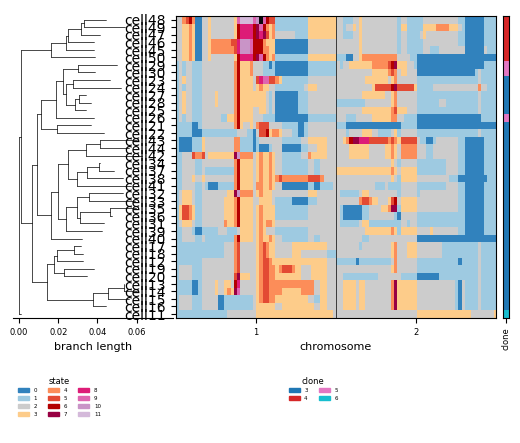

In [24]:
# output tree
# print(inferred_tree)
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=inferred_tree, annotation_fields=['clone'], show_cell_ids=True)


In [12]:
print(inferred_tree)

Tree(rooted=False, weight=1.0)
    Clade(name='root')
        Clade(branch_length=6.829978051389932e-15, name='ancestor1')
            Clade(branch_length=6.829978051389932e-15, name='ancestor2')
                Clade(branch_length=1.3659956102779864e-14, name='ancestor3')
                    Clade(branch_length=2.7319912205559728e-14, name='ancestor4')
                        Clade(branch_length=5.4639824411119456e-14, name='ancestor5')
                            Clade(branch_length=1.0927964882223891e-13, name='ancestor6')
                                Clade(branch_length=8.95235076603404e-12, name='ancestor7')
                                    Clade(branch_length=0.001779955779563772, name='ancestor8')
                                        Clade(branch_length=0.005105647151597669, name='cell8')
                                        Clade(branch_length=0.003521362748037286, name='cell9')
                                    Clade(branch_length=0.0034073165531906587, name='cel

In [47]:
adata.uns['cnasim-params']


{'Time': 2,
 'WGD': False,
 'bin_length': 1000000,
 'chrom_arm_rate': 0.75,
 'chrom_arm_ratio': 0.5,
 'chrom_event_type': 0.5,
 'chrom_length': 50000000,
 'chrom_level_event': False,
 'chrom_rate_clone': 1,
 'chrom_rate_founder': 2,
 'chrom_rate_super_clone': 1,
 'clone_criteria': 0,
 'cn_copy_param': 0.8,
 'cn_event_rate': 0.5,
 'cn_length_mean': 10000000,
 'coverage': 0.2,
 'disable_info': False,
 'error_rate_1': 0.04,
 'error_rate_2': 0.1,
 'founder_event_mult': 10,
 'growth_rate': 0.003785,
 'interval': 3,
 'lorenz_x': 0.5,
 'lorenz_y': 0.4,
 'min_cn_length': 1000,
 'mode': 1,
 'normal_fraction': 0.2,
 'num_cells': 10,
 'num_chromosomes': 2,
 'num_clones': 2,
 'num_sweep': 0,
 'out_path': ' results/data/R1_N10_M100_K2_L2_E10.04_E20.1_C2/cnasim_tmp',
 'placement_param': 2,
 'placement_type': 0,
 'processors': 1,
 'pseudonormal_fraction': 0,
 'read_length': 150,
 'region_length': 1000,
 'selection_strength': 0.01,
 'seq_error': 0.02,
 'tree_type': 0,
 'use_hg38_static': False,
 'use_